In [1]:
import sys
sys.executable

'/home/ksmehrab/miniconda/envs/data_env/bin/python'

In [2]:
import re
import numpy as np
from transformers import AutoModelForCausalLM, AutoProcessor, GenerationConfig
from PIL import Image, ImageDraw
import pandas as pd 
import os 
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

def get_molmo_output(
    pil_image,
    text_prompt,
    processor,
    model
):
    # process the image and text
    inputs = processor.process(
        images=[pil_image],
        text=text_prompt
    )
    
    # move inputs to the correct device and make a batch of size 1
    inputs = {k: v.to(model.device).unsqueeze(0) for k, v in inputs.items()}
    
    # generate output; maximum 200 new tokens; stop generation when <|endoftext|> is generated
    output = model.generate_from_batch(
        inputs,
        GenerationConfig(max_new_tokens=200, stop_strings="<|endoftext|>"),
        tokenizer=processor.tokenizer
    )
    
    # only get generated tokens; decode them to text
    generated_tokens = output[0,inputs['input_ids'].size(1):]
    generated_text = processor.tokenizer.decode(generated_tokens, skip_special_tokens=True)
    
    # print the generated text
    # print(generated_text)
    return generated_text

def extract_points(molmo_output, image_w, image_h):
    """
    https://huggingface.co/allenai/Molmo-7B-O-0924/discussions/1
    """
    all_points = []
    for match in re.finditer(r'x\d*="\s*([0-9]+(?:\.[0-9]+)?)"\s+y\d*="\s*([0-9]+(?:\.[0-9]+)?)"', molmo_output):
        try:
            point = [float(match.group(i)) for i in range(1, 3)]
        except ValueError:
            pass
        else:
            point = np.array(point)
            if np.max(point) > 100:
                # Treat as an invalid output
                continue
            point /= 100.0
            point = point * np.array([image_w, image_h])
            all_points.append(point)
    return all_points

def visualize_points(image, points, point_size=5, point_color="#FF0000"):
    """
    Visualize and display predicted points on the image.
    
    Args:
        image: PIL Image object or path to image
        points: List of (x,y) points to visualize
        point_size: Size of the points to draw (default: 5)
        point_color: Color of points in hex format (default: red)
    """
    
    # If image is a path, load it
    if isinstance(image, str):
        image = Image.open(image).convert('RGB')
    
    # Create a copy of the image to draw on
    img_draw = image.copy()
    draw = ImageDraw.Draw(img_draw)
    
    # Draw each point as a filled circle
    for point in points:
        x, y = point
        draw.ellipse([x-point_size, y-point_size, x+point_size, y+point_size], 
                    fill=point_color)
    
    # Display the image with points
    plt.figure(figsize=(12, 8))
    plt.imshow(img_draw)
    plt.axis('off')  # Hide axes
    plt.show()


In [3]:
# Set the molmo name
molmo_name='allenai/Molmo-7B-D-0924'

# load the processor
processor = AutoProcessor.from_pretrained(
    molmo_name,
    trust_remote_code=True,
    torch_dtype='auto',
    device_map='auto'
)

# load the molmo model
model = AutoModelForCausalLM.from_pretrained(
    molmo_name,
    trust_remote_code=True,
    torch_dtype='auto',
    device_map='auto'
)


Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

In [4]:
# Set the img dir and the img filenames that need to be iterated 
img_dir = '/data/InvasivePlantsData/png-512/session_2_1_18_2025/'
data_file = '/home/ksmehrab/InvasivePlants/Segmentation/sample_images.csv'
output_dir = '/data/InvasivePlantsResults/MolmoUnbatchedPoints'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [ ]:
# Get the image filenames 
required_images = list(pd.read_csv(data_file).filename)
required_images = [img_filename for img_filename in required_images if os.path.splitext(img_filename)[0]+'.npy' not in os.listdir(output_dir)]


  0%|          | 0/1 [00:00<?, ?it/s]

 <points x1="46.5" y1="48.6" x2="52.9" y2="59.6" alt="damaged regions in the leaf">damaged regions in the leaf</points>


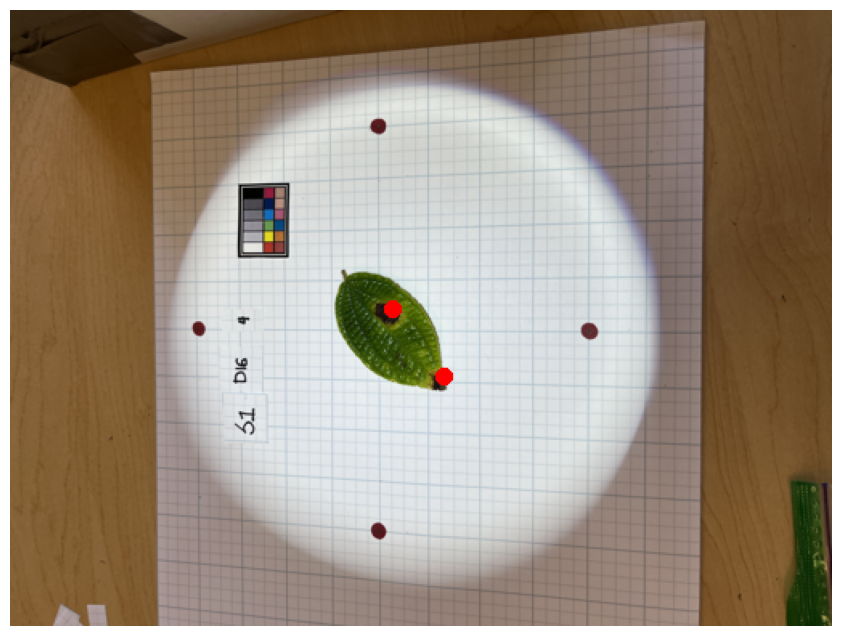

100%|██████████| 1/1 [00:04<00:00,  4.56s/it]

Done all! Failed on 0 images


In [6]:
images_that_failed = []
for img_filename in tqdm(required_images):
    # Set the name of the output dir and file 
    
    output_file = os.path.join(output_dir, f'{os.path.splitext(img_filename)[0]}.npy')
    # print(f'Performing on trait {trait_name}')

    # Main loop 
    save_dict = {}

    img = Image.open(os.path.join(img_dir, img_filename)).convert('RGB')
    # try:
    molmo_output = get_molmo_output(
        pil_image = img, 
        text_prompt = f'Point to the damaged regions in the leaf',
        processor = processor,
        model = model
    )
    print(molmo_output)
    # except:
    #     print(f'Failed!')
    #     images_that_failed.append(img_filename)
    #     continue

    points = extract_points(molmo_output, img.size[0], img.size[1])
    save_dict['damaged_regions'] = points

    # Method to visualize points on the image 
    visualize_points(img, points)
     
    # Save the output as npy file 
    # print(f'Saving to {output_file}')
    # breakpoint()
    np.save(output_file, save_dict)

# Write the images that failed to a file
# if len(images_that_failed) > 0:
#     with open(os.path.join(output_dir, 'images_that_failed.txt'), 'w') as f:
#         for item in images_that_failed:
#             f.write(item + '\n')

print(f'Done all! Failed on {len(images_that_failed)} images')